# SAIR — Module 5, Notebook 4: Training GPT from Scratch

## Introduction

You've built the data pipeline, understood attention, and assembled the GPT architecture. Now it's time to **bring the model to life through training**.

This notebook takes you from a bare-minimum training loop all the way to the techniques used to train GPT-2 and GPT-3 at scale. Every trainer version is a direct upgrade of the last — you'll see exactly what changes and why.

### The Trainer Evolution

| Version | What's New |
|---------|------------|
| `trainerV0` | Forward → Loss → Backward → Step. Overfit a single batch. |
| `trainerV1` | + Full dataset loop + evaluation + text generation + checkpoints |
| `trainerV2` | + TF32 + Mixed Precision (FP16) + `torch.compile` + Flash Attention |
| `trainerV3` | + Gradient clipping + LR scheduling + Gradient accumulation |
| `trainerV4` | + DDP multi-GPU (production scale — code snippet) |

### What You Will Learn
1. The four fundamental steps of every training loop
2. How to monitor training with loss curves and live text generation
3. Hardware tricks that speed up training without changing the math
4. Algorithmic tricks that improve stability and convergence
5. How real LLMs are trained across hundreds of GPUs

In [7]:
# ── Colab / Environment Setup ──────────────────────────────────────────
import os, sys, glob
import numpy as np

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('SAIR'):
        os.system('git clone https://github.com/silvaxxx1/SAIR.git')
    # UTILS/ lives inside 5_GPT from scratch/
    sys.path.insert(0, 'SAIR/5_GPT from scratch/')
    DATA_DIR  = 'SAIR/5_GPT from scratch/data'
    BOOKS_DIR = 'SAIR/4_Applied Deep Learning with PyTorch/3_Sequence and NLP/harry_potter_txt/'
else:
    # CWD is already 5_GPT from scratch/ — UTILS/ is right here
    sys.path.insert(0, '.')
    DATA_DIR  = 'data'
    BOOKS_DIR = '../4_Applied Deep Learning with PyTorch/3_Sequence and NLP/harry_potter_txt/'

# ── Auto-generate .bin files if missing ────────────────────────────────
os.makedirs(DATA_DIR, exist_ok=True)
train_bin = os.path.join(DATA_DIR, 'train_ids.bin')

if not os.path.exists(train_bin):
    print("Data files not found — generating from Harry Potter books...")
    import tiktoken

    book_files = sorted(glob.glob(os.path.join(BOOKS_DIR, '*.txt')))
    if not book_files:
        raise FileNotFoundError(
            f"No .txt books found in {BOOKS_DIR}\n"
            "Please make sure the Harry Potter books are in that directory."
        )

    full_text = '\n\n'.join(open(p, encoding='utf-8').read() for p in book_files)
    n = len(full_text)
    tokenizer_prep = tiktoken.encoding_for_model('gpt2')

    for split, text in [
        ('train', full_text[:int(n * 0.90)]),
        ('val',   full_text[int(n * 0.90):int(n * 0.97)]),
        ('test',  full_text[int(n * 0.97):]),
    ]:
        ids = np.array(tokenizer_prep.encode(text), dtype=np.int32)
        ids.tofile(os.path.join(DATA_DIR, f'{split}_ids.bin'))
        print(f"  {split:5s}: {len(ids):,} tokens saved")

    print("Done — data ready.")
else:
    print("Data files found — skipping generation.")

print(f'Running on : {"Colab" if IN_COLAB else "Local"}')
print(f'Data dir   : {DATA_DIR}')

Data files found — skipping generation.
Running on : Colab
Data dir   : SAIR/5_GPT from scratch/data


In [8]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import tiktoken

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


---
## Section 1 — Data Pipeline

We load the preprocessed `.bin` files from Notebook 1 and wrap them in PyTorch `DataLoader`s.
Nothing new here — this is the same pipeline you built. We just plug it in and move on.

In [9]:
class GPT2Dataset(Dataset):
    def __init__(self, file_path, max_length, stride):
        self.data       = np.fromfile(file_path, dtype=np.int32)
        self.max_length = max_length
        self.stride     = stride

    def __len__(self):
        return (len(self.data) - self.max_length) // self.stride

    def __getitem__(self, idx):
        start = idx * self.stride
        x = torch.tensor(self.data[start : start + self.max_length], dtype=torch.long)
        y = torch.tensor(self.data[start + 1 : start + self.max_length + 1], dtype=torch.long)
        return x, y


# Paths set by setup cell above — works on Colab and local
train_path = f"{DATA_DIR}/train_ids.bin"
val_path   = f"{DATA_DIR}/val_ids.bin"
test_path  = f"{DATA_DIR}/test_ids.bin"
# Note: run 1.DATA.ipynb first to generate these .bin files

MAX_LEN = 256
STRIDE  = 128
BATCH   = 4

torch.manual_seed(123)

train_dataset = GPT2Dataset(train_path, MAX_LEN, STRIDE)
val_dataset   = GPT2Dataset(val_path,   MAX_LEN, STRIDE)
test_dataset  = GPT2Dataset(test_path,  MAX_LEN, STRIDE)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False, drop_last=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 3398
Val   batches : 267
Test  batches : 110


---
## Section 2 — Model Setup

We use two configurations throughout this notebook:
- **CPU-friendly** — reduced size for running locally without a GPU
- **GPT-124M** — the original GPT-2 small configuration (use on GPU)

We import the `GPTModel` built in Notebook 3. Later we define `GPTModel_FLASH`, an upgraded version that swaps in Flash Attention.

In [10]:
# sys.path already set in the setup cell above
from UTILS.model import GPTModel

# Reduced config — CPU friendly
GPT_CONFIG_CPU = {
    "vocab_size"     : 50257,
    "context_length" : 256,
    "emb_dim"        : 512,
    "n_heads"        : 8,
    "n_layers"       : 6,
    "drop_rate"      : 0.1,
    "qkv_bias"       : False,
}

# Full GPT-2 small — use on GPU
GPT_CONFIG_124M = {
    "vocab_size"     : 50257,
    "context_length" : 1024,
    "emb_dim"        : 768,
    "n_heads"        : 12,
    "n_layers"       : 12,
    "drop_rate"      : 0.1,
    "qkv_bias"       : False,
}

ACTIVE_CONFIG = GPT_CONFIG_CPU   # swap to GPT_CONFIG_124M when on GPU

model = GPTModel(ACTIVE_CONFIG)
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 70,500,352


---
## Section 3 — Helper Functions

These utilities are shared by all trainer versions:
- **Loss helpers** — compute loss for a single batch or average across a loader
- **Evaluation** — switch to eval mode, compute train + val loss
- **Text generation** — greedy decoding to watch the model learn live during training

In [11]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    return F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())


def calc_loss_loader(data_loader, model, device, num_batches=None):
    if len(data_loader) == 0:
        return float("nan")
    num_batches = min(num_batches or len(data_loader), len(data_loader))
    total = 0.0
    for i, (x, y) in enumerate(data_loader):
        if i >= num_batches:
            break
        total += calc_loss_batch(x, y, model, device).item()
    return total / num_batches

In [12]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        idx_next = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


def text_to_token_ids(text, tokenizer):
    return torch.tensor(
        tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    ).unsqueeze(0)


def token_ids_to_text(ids, tokenizer):
    return tokenizer.decode(ids.squeeze(0).tolist())


def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=50):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model, encoded, max_new_tokens, context_size)
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


tokenizer = tiktoken.encoding_for_model("gpt2")
print("Helpers ready.")

Helpers ready.


---
## Section 4 — trainerV0: The Core Loop

### The Four Steps of Every Training Loop

From this toy version to GPT-4, every training step does exactly four things:

```
1. Forward pass   →  model(input) produces logits
2. Loss           →  cross_entropy(logits, targets) measures how wrong we are
3. Backward pass  →  loss.backward() computes gradients
4. Weight update  →  optimizer.step() moves weights downhill
```

### Sanity Check: Overfit on a Single Batch

**Before training on the full dataset, always verify your loop works.**  
Overfit a single batch — if the loss doesn't drop close to zero in ~50 steps, something is broken.  
Catching this here is cheap. Catching it after a 10-hour training run is not.

> Goal: loss should fall from ~10.9 → < 0.01 in 50 epochs on the same batch.

In [13]:
def trainerV0(model, single_batch, optimizer, device, num_epochs):
    """Bare minimum — overfit a single batch to verify the loop works."""
    input_batch, target_batch = single_batch
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)

    losses = []
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()                                           # reset gradients
        loss = calc_loss_batch(input_batch, target_batch, model, device) # forward + loss
        loss.backward()                                                 # backward
        optimizer.step()                                                # update weights
        losses.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

    return losses

Epoch  10 | Loss: 2.8079
Epoch  20 | Loss: 0.2458
Epoch  30 | Loss: 0.0343
Epoch  40 | Loss: 0.0104
Epoch  50 | Loss: 0.0057


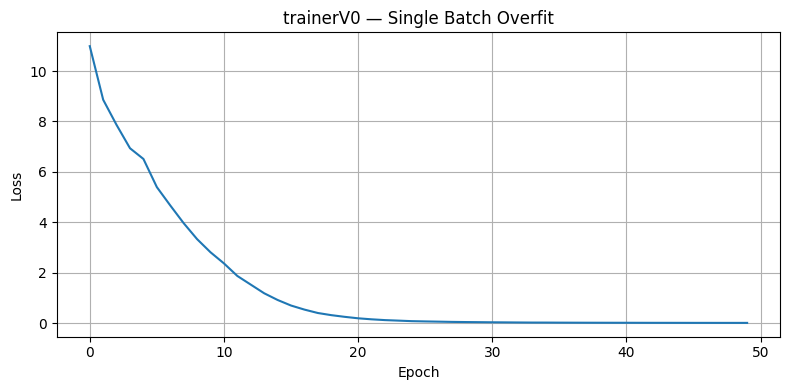

Final loss: 0.0057  (should be near 0)


In [14]:
torch.manual_seed(123)
model_v0 = GPTModel(ACTIVE_CONFIG).to(device)
optim_v0 = torch.optim.Adam(model_v0.parameters(), lr=0.001)
one_batch = next(iter(train_loader))

losses_v0 = trainerV0(model_v0, one_batch, optim_v0, device, num_epochs=50)

plt.figure(figsize=(8, 4))
plt.plot(losses_v0)
plt.title("trainerV0 — Single Batch Overfit")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Final loss: {losses_v0[-1]:.4f}  (should be near 0)")

---
## Section 5 — trainerV1: Full Training Loop

V0 proved the four steps work. Now we train on the full dataset.

Three things are added on top of V0 — each marked `# [V1]` in the code:

1. **Epoch loop over all batches** — iterate through the whole dataset each epoch
2. **Periodic evaluation** — compute train/val loss every `eval_freq` steps to monitor progress
3. **Live text generation** — generate a sample after each epoch so we can see the model learning
4. **Model checkpointing** — save weights after each epoch so we can resume or do inference

In [15]:
def trainerV1(model, train_loader, val_loader, optimizer, device, num_epochs,
              eval_freq, eval_iter, start_context, tokenizer, save_path):
    """Full training loop: dataset loop + evaluation + text generation + checkpoints."""

    os.makedirs(save_path, exist_ok=True)                      # [V1] ensure checkpoint dir
    train_losses, val_losses, tokens_seen = [], [], []         # [V1] tracking lists
    total_tokens, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:         # [V1] full dataset loop
            t0 = time.time()
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            total_tokens += input_batch.numel()                # [V1] token counter
            global_step  += 1

            if global_step % eval_freq == 0:                   # [V1] periodic evaluation
                tr_loss, vl_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tr_loss)
                val_losses.append(vl_loss)
                tokens_seen.append(total_tokens)
                dt = time.time() - t0
                print(f"Ep {epoch+1} | Step {global_step:05d} | "
                      f"Train {tr_loss:.3f} | Val {vl_loss:.3f} | {dt*1000:.0f}ms")

        generate_and_print_sample(                             # [V1] live text generation
            model, tokenizer, device, start_context)

        torch.save(model.state_dict(),                         # [V1] checkpoint
                   f"{save_path}/model_epoch_{epoch+1}.pt")
        print(f"Checkpoint saved — epoch {epoch+1}")

    return train_losses, val_losses, tokens_seen

In [16]:
torch.manual_seed(123)
model_v1 = GPTModel(ACTIVE_CONFIG).to(device)
optim_v1 = torch.optim.AdamW(model_v1.parameters(), lr=4e-4, weight_decay=0.1)

tr_losses, vl_losses, tokens_seen = trainerV1(
    model_v1, train_loader, val_loader, optim_v1, device,
    num_epochs    = 3,
    eval_freq     = 50,
    eval_iter     = 5,
    start_context = "Every effort moves you",
    tokenizer     = tokenizer,
    save_path     = "checkpoints",
)

Ep 1 | Step 00000 | Train 10.004 | Val 9.988 | 503ms
Ep 1 | Step 00050 | Train 5.388 | Val 5.117 | 525ms
Ep 1 | Step 00100 | Train 4.991 | Val 4.768 | 531ms
Ep 1 | Step 00150 | Train 4.991 | Val 4.586 | 536ms
Ep 1 | Step 00200 | Train 4.665 | Val 4.451 | 536ms
Ep 1 | Step 00250 | Train 4.725 | Val 4.372 | 541ms
Ep 1 | Step 00300 | Train 4.626 | Val 4.272 | 543ms
Ep 1 | Step 00350 | Train 4.554 | Val 4.192 | 548ms
Ep 1 | Step 00400 | Train 4.166 | Val 4.102 | 550ms
Ep 1 | Step 00450 | Train 4.094 | Val 4.033 | 555ms
Ep 1 | Step 00500 | Train 4.353 | Val 3.993 | 557ms
Ep 1 | Step 00550 | Train 4.030 | Val 3.935 | 563ms
Ep 1 | Step 00600 | Train 4.212 | Val 3.879 | 567ms
Ep 1 | Step 00650 | Train 4.185 | Val 3.836 | 568ms
Ep 1 | Step 00700 | Train 4.046 | Val 3.787 | 569ms
Ep 1 | Step 00750 | Train 3.876 | Val 3.757 | 567ms
Ep 1 | Step 00800 | Train 3.575 | Val 3.737 | 564ms
Ep 1 | Step 00850 | Train 3.978 | Val 3.719 | 568ms
Ep 1 | Step 00900 | Train 3.644 | Val 3.735 | 566ms
Ep 1 | Step

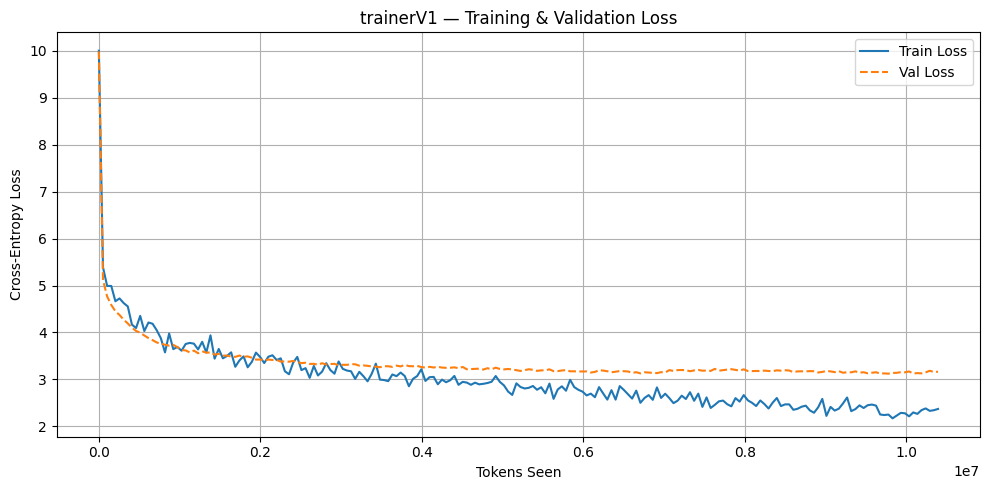

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tokens_seen, tr_losses, label="Train Loss")
ax.plot(tokens_seen, vl_losses, label="Val Loss", linestyle="--")
ax.set_xlabel("Tokens Seen")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("trainerV1 — Training & Validation Loss")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## Section 6 — trainerV2: Hardware Speed Tricks

V1 is correct but slow. Before touching the algorithm, we squeeze speed from the hardware.  
Four techniques — each requiring very little code.

### 6.1 — TF32: Free Speedup on Modern GPUs

Modern NVIDIA GPUs (Ampere A100, Hopper H100) have **TensorCores** — silicon designed to accelerate matrix multiplications. By default PyTorch uses full FP32. Switching to **TF32** routes matrix multiplications through TensorCores at slightly reduced precision but **~3x faster throughput**.

> One line. No meaningful accuracy loss. Always enable on Ampere+ GPUs.

In [18]:
# Route matrix multiplications through TensorCores (Ampere/Hopper GPUs)
torch.set_float32_matmul_precision("high")
print("TF32 matmul precision enabled.")

TF32 matmul precision enabled.


### 6.2 — Mixed Precision (FP16)

We go further by running the **forward pass in FP16** (half precision) while keeping the **optimizer state in FP32**.  
This halves memory bandwidth and unlocks faster TensorCore paths.

- **FP16** — fast, but can underflow → needs `GradScaler` for stability  
- **BF16** — same range as FP32, fewer instability issues → preferred on Ampere+

Rule: `torch.autocast` wraps **only the forward pass**. The backward pass stays in FP32.

In [19]:
# Conceptual example — shown standalone, integrated into trainerV2 below

# scaler = torch.cuda.amp.GradScaler()              # handles FP16 underflow

# with torch.autocast(device_type="cuda", dtype=torch.float16):  # FP16 forward only
#     logits = model(input_batch)
#     loss   = F.cross_entropy(logits.flatten(0,1), target_batch.flatten())

# scaler.scale(loss).backward()   # scaled backward stays in FP32
# scaler.step(optimizer)
# scaler.update()

print("Mixed precision pattern above — integrated into trainerV2.")

Mixed precision pattern above — integrated into trainerV2.


### 6.3 — torch.compile()

```python
model = torch.compile(model)
```

PyTorch traces the entire model graph and **fuses operations**, reducing Python overhead and GPU memory round-trips. The first forward pass is slower (compilation), but every subsequent one is faster.

> Use by default unless you are actively debugging.

### 6.4 — Flash Attention

Standard attention computes the full `(T × T)` attention matrix in HBM (slow GPU memory).  
**Flash Attention** tiles the computation so it never materializes the full matrix — it stays in fast on-chip SRAM.

PyTorch 2.0+ exposes this through a single function call:
```python
F.scaled_dot_product_attention(q, k, v, is_causal=True)
```
This replaces the entire manual attention computation from Notebook 2.  
Below we define `GPTModel_FLASH` — identical to Notebook 3's model, only the attention layer changes.

In [20]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(config["emb_dim"], 4 * config["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * config["emb_dim"], config["emb_dim"]),
        )
    def forward(self, x):
        return self.layers(x)


class FlashAttention(nn.Module):
    """Drop-in replacement for MultiHeadAttention using F.scaled_dot_product_attention."""
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=bias)
        self.W_value = nn.Linear(d_in, d_out, bias=bias)
        self.proj    = nn.Linear(d_out, d_out)
        self.dropout = dropout

    def forward(self, x):
        b, T, _ = x.shape
        q = self.W_query(x).view(b, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, T, self.num_heads, self.head_dim).transpose(1, 2)
        # PyTorch handles causal masking, softmax, dropout — all in SRAM
        out = F.scaled_dot_product_attention(
            q, k, v, is_causal=True,
            dropout_p=self.dropout if self.training else 0.0
        )
        out = out.transpose(1, 2).contiguous().view(b, T, self.d_out)
        return self.proj(out)


class TransformerBlockFlash(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.att  = FlashAttention(
            config["emb_dim"], config["emb_dim"],
            config["context_length"], config["drop_rate"],
            config["n_heads"], config["qkv_bias"]
        )
        self.ff    = FeedForward(config)
        self.norm1 = nn.LayerNorm(config["emb_dim"])
        self.norm2 = nn.LayerNorm(config["emb_dim"])
        self.drop  = nn.Dropout(config["drop_rate"])

    def forward(self, x):
        x = x + self.drop(self.att(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x


class GPTModel_FLASH(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config["vocab_size"],     config["emb_dim"])
        self.pos_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.drop    = nn.Dropout(config["drop_rate"])
        self.blocks  = nn.Sequential(
            *[TransformerBlockFlash(config) for _ in range(config["n_layers"])]
        )
        self.norm    = nn.LayerNorm(config["emb_dim"])
        self.head    = nn.Linear(config["emb_dim"], config["vocab_size"], bias=False)

    def forward(self, x):
        B, T = x.shape
        pos  = torch.arange(T, device=x.device).unsqueeze(0)
        x    = self.drop(self.tok_emb(x) + self.pos_emb(pos))
        x    = self.blocks(x)
        return self.head(self.norm(x))


print("GPTModel_FLASH defined — uses F.scaled_dot_product_attention internally.")

GPTModel_FLASH defined — uses F.scaled_dot_product_attention internally.


### trainerV2 — What Changed vs V1

```diff
  model = GPTModel_FLASH(config)              # Flash Attention model
+ model = torch.compile(model)               # [V2] kernel fusion
+ torch.set_float32_matmul_precision('high') # [V2] TF32
+ scaler = torch.cuda.amp.GradScaler()       # [V2] FP16 stability

- loss = calc_loss_batch(x, y, model, device)
+ with torch.autocast(device_type='cuda', dtype=torch.float16):  # [V2] FP16 forward
+     logits = model(x)
+     loss   = F.cross_entropy(...)

- loss.backward()
- optimizer.step()
+ scaler.scale(loss).backward()   # [V2] scaled backward
+ scaler.step(optimizer)          # [V2]
+ scaler.update()                 # [V2]
```

Everything else — evaluation, text generation, checkpointing — is identical to V1.

In [21]:
def trainerV2(model, train_loader, val_loader, optimizer, device, num_epochs,
              eval_freq, eval_iter, start_context, tokenizer, save_path):
    """V1 + TF32 + Mixed Precision (FP16) + Flash Attention + torch.compile."""

    os.makedirs(save_path, exist_ok=True)
    train_losses, val_losses, tokens_seen = [], [], []
    total_tokens, global_step = 0, -1

    scaler = torch.cuda.amp.GradScaler()                               # [V2] FP16 scaler

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            t0 = time.time()
            input_batch  = input_batch.to(device)
            target_batch = target_batch.to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type=device, dtype=torch.float16):  # [V2] FP16 forward
                logits = model(input_batch)
                loss   = F.cross_entropy(
                    logits.flatten(0, 1), target_batch.flatten())

            scaler.scale(loss).backward()                                  # [V2] scaled backward
            scaler.step(optimizer)                                         # [V2]
            scaler.update()                                                # [V2]

            total_tokens += input_batch.numel()
            global_step  += 1

            if global_step % eval_freq == 0:
                tr_loss, vl_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tr_loss)
                val_losses.append(vl_loss)
                tokens_seen.append(total_tokens)
                dt = time.time() - t0
                print(f"Ep {epoch+1} | Step {global_step:05d} | "
                      f"Train {tr_loss:.3f} | Val {vl_loss:.3f} | {dt*1000:.0f}ms")

        generate_and_print_sample(model, tokenizer, device, start_context)
        torch.save(model.state_dict(), f"{save_path}/model_epoch_{epoch+1}.pt")
        print(f"Checkpoint saved — epoch {epoch+1}")

    return train_losses, val_losses, tokens_seen

In [22]:
# Note: torch.compile adds one-time overhead on the first batch but every batch after is faster
torch.manual_seed(123)
model_v2 = GPTModel_FLASH(ACTIVE_CONFIG).to(device)

if device == "cuda":
    torch.set_float32_matmul_precision("high")
    model_v2 = torch.compile(model_v2)

optim_v2 = torch.optim.AdamW(
    model_v2.parameters(),
    lr=4e-4, weight_decay=0.1,
    betas=(0.9, 0.95)   # same betas used for GPT-2 and GPT-3
)

tr_losses_v2, vl_losses_v2, tokens_seen_v2 = trainerV2(
    model_v2, train_loader, val_loader, optim_v2, device,
    num_epochs    = 3,
    eval_freq     = 50,
    eval_iter     = 5,
    start_context = "Every effort moves you",
    tokenizer     = tokenizer,
    save_path     = "checkpoints",
)

/tmp/ipykernel_1994/4030820707.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()                               # [V2] FP16 scaler
W0417 18:38:01.745000 1994 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Ep 1 | Step 00000 | Train 10.007 | Val 9.991 | 34509ms
Ep 1 | Step 00050 | Train 5.386 | Val 5.110 | 364ms
Ep 1 | Step 00100 | Train 4.992 | Val 4.768 | 365ms
Ep 1 | Step 00150 | Train 5.003 | Val 4.598 | 367ms
Ep 1 | Step 00200 | Train 4.677 | Val 4.467 | 367ms
Ep 1 | Step 00250 | Train 4.767 | Val 4.407 | 369ms
Ep 1 | Step 00300 | Train 4.652 | Val 4.310 | 370ms
Ep 1 | Step 00350 | Train 4.602 | Val 4.239 | 373ms
Ep 1 | Step 00400 | Train 4.224 | Val 4.173 | 371ms
Ep 1 | Step 00450 | Train 4.160 | Val 4.101 | 373ms
Ep 1 | Step 00500 | Train 4.458 | Val 4.072 | 372ms
Ep 1 | Step 00550 | Train 4.107 | Val 4.003 | 372ms
Ep 1 | Step 00600 | Train 4.304 | Val 3.951 | 368ms
Ep 1 | Step 00650 | Train 4.278 | Val 3.907 | 365ms
Ep 1 | Step 00700 | Train 4.162 | Val 3.881 | 370ms
Ep 1 | Step 00750 | Train 3.980 | Val 3.850 | 366ms
Ep 1 | Step 00800 | Train 3.669 | Val 3.804 | 364ms
Ep 1 | Step 00850 | Train 4.078 | Val 3.786 | 366ms
Ep 1 | Step 00900 | Train 3.751 | Val 3.814 | 364ms
Ep 1 | St

---
## Section 7 — trainerV3: Algorithmic Tricks

Hardware tricks made it faster. Now we make it **smarter and more stable**.

### 7.1 — Gradient Clipping

During early training, gradients can spike and cause the loss to explode.  
**Gradient clipping** caps the global gradient norm to a maximum value (1.0 is standard):

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

Call it **after** `loss.backward()` and **before** `optimizer.step()`.

### 7.2 — Learning Rate Scheduling (Cosine Annealing)

A fixed learning rate is suboptimal: too high early causes instability, too high late prevents convergence.  
**Cosine annealing** starts at a peak LR and smoothly decays to near-zero following a cosine curve.  
GPT-2 and GPT-3 use cosine decay with a short **linear warmup** at the beginning.

```python
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scheduler.step()  # called after each optimizer.step()
```

### 7.3 — Gradient Accumulation (Simulating Large Batches)

GPT-3 trained with batch sizes of **~0.5 million tokens**. A single GPU can hold only a tiny micro-batch.  
**Gradient accumulation** simulates a large batch: run multiple micro-batches, accumulate their gradients, then call `optimizer.step()` once at the end.

```python
total_batch   = 524288  # 0.5M tokens (GPT-3 scale)
micro_batch   = 16      # what fits in GPU memory
grad_accum    = total_batch // (micro_batch * sequence_length)
loss = loss / grad_accum   # normalize so the total equals one large-batch update
```

### trainerV3 — What Changed vs V2

```diff
+ grad_accum = total_batch // (micro_batch * seq_len)   # [V3] accumulation steps
+ for step in range(grad_accum):                        # [V3] outer accumulation loop
+     for micro_step in range(micro_batch):             # [V3] inner micro-batch loop
+         loss = loss / grad_accum                      # [V3] normalize loss
+     clip_grad_norm_(model.parameters(), 1.0)          # [V3] gradient clipping
+     scheduler.step()                                  # [V3] LR scheduling
```

In [23]:
def trainerV3(model, train_loader, val_loader, optimizer, device, num_epochs,
              eval_freq, eval_iter, start_context, tokenizer, save_path,
              scheduler, total_batch, micro_batch, sequence_length, criterion):
    """V2 + gradient clipping + cosine LR scheduling + gradient accumulation."""

    os.makedirs(save_path, exist_ok=True)

    # [V3] Number of micro-batch groups that form one effective large batch
    grad_accum = total_batch // (micro_batch * sequence_length)
    print(f"Gradient accumulation steps: {grad_accum} "
          f"(effective batch = {total_batch:,} tokens)")

    train_losses, val_losses, tokens_seen = [], [], []
    total_tokens, global_step = 0, -1
    train_iter = iter(train_loader)

    for epoch in range(num_epochs):
        model.train()
        epoch_t0 = time.time()

        for step in range(grad_accum):                               # [V3] accumulation outer loop
            optimizer.zero_grad()
            loss_accum = 0.0

            for _ in range(micro_batch):                             # [V3] micro-batch inner loop
                try:
                    x, y = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    x, y = next(train_iter)

                x, y = x.to(device), y.to(device)

                with torch.autocast(device_type=device, dtype=torch.float16):
                    logits = model(x)

                loss       = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
                loss       = loss / grad_accum                       # [V3] normalize
                loss_accum += loss.detach()
                loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # [V3] clipping
            optimizer.step()
            scheduler.step()                                          # [V3] LR step

            total_tokens += x.numel()
            global_step  += 1

            if global_step % eval_freq == 0:
                tr_loss, vl_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tr_loss)
                val_losses.append(vl_loss)
                tokens_seen.append(total_tokens)
                lr_now = scheduler.get_last_lr()[0]
                print(f"Ep {epoch+1} | Step {global_step:05d} | "
                      f"Train {tr_loss:.3f} | Val {vl_loss:.3f} | LR {lr_now:.2e}")

        generate_and_print_sample(model, tokenizer, device, start_context)
        epoch_time = time.time() - epoch_t0
        print(f"Epoch {epoch+1} done in {epoch_time:.1f}s")
        torch.save(model.state_dict(), f"{save_path}/model_epoch_{epoch+1}.pt")

    return train_losses, val_losses, tokens_seen

In [24]:
torch.manual_seed(123)
model_v3   = GPTModel_FLASH(ACTIVE_CONFIG).to(device)
num_epochs = 3

if device == "cuda":
    model_v3 = torch.compile(model_v3)

optim_v3  = torch.optim.AdamW(
    model_v3.parameters(),
    lr=4e-4, weight_decay=0.1, betas=(0.9, 0.95), eps=1e-8
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim_v3, T_max=num_epochs)
criterion = nn.CrossEntropyLoss()

tr_losses_v3, vl_losses_v3, tokens_seen_v3 = trainerV3(
    model_v3, train_loader, val_loader, optim_v3, device,
    num_epochs     = num_epochs,
    eval_freq      = 50,
    eval_iter      = 5,
    start_context  = "Every effort moves you",
    tokenizer      = tokenizer,
    save_path      = "checkpoints",
    scheduler      = scheduler,
    total_batch    = 32768,   # scale up to 524288 on real GPU hardware
    micro_batch    = 4,
    sequence_length= MAX_LEN,
    criterion      = criterion,
)

Gradient accumulation steps: 32 (effective batch = 32,768 tokens)
Ep 1 | Step 00000 | Train 9.899 | Val 9.877 | LR 3.00e-04
Every effort moves you.  ”  “.  ”  “”  ”  ”  “”  “”  ”  ”  
Epoch 1 done in 5.0s
Ep 2 | Step 00050 | Train 6.078 | Val 5.843 | LR 0.00e+00
Every effort moves you                                                  
Epoch 2 done in 4.9s
Every effort moves you,  ”  “”  ” said,”  ”  ” said,” said,”  ” said,  ” said,” 
Epoch 3 done in 4.6s


---
## Section 8 — trainerV4: Multi-GPU Training at Scale

Everything so far runs on a single GPU. Real language models do not.

- GPT-2 (124M) — trained on **8 V100 GPUs**
- GPT-3 (175B) — **1,024 A100 GPUs**, ~3 months, ~$5M in compute
- LLaMA-3 (70B) — **~15,000 H100 GPUs**

### 8.1 — Data Parallelism vs Model Parallelism

| | Data Parallelism | Model Parallelism |
|---|---|---|
| **Idea** | Full model on each GPU; each GPU gets a different data slice | Model layers split across GPUs |
| **When to use** | Model fits in one GPU | Model is too large for one GPU |
| **Gradient sync** | AllReduce after each backward | Point-to-point between layers |
| **PyTorch API** | `DistributedDataParallel` (DDP) | `DeviceMesh` / DeepSpeed / Megatron |

For GPT-2 scale, **DDP is sufficient**. V4 implements DDP.

### 8.2 — How DDP Works

1. Each GPU (rank) holds a **full copy of the model**
2. `DistributedSampler` ensures each GPU sees a **unique, non-overlapping data slice**
3. After `loss.backward()`, PyTorch **AllReduces gradients** across GPUs — each ends up with the average
4. Every GPU applies the same `optimizer.step()` → **all copies stay in sync**

Result: effective batch size scales with the number of GPUs. Throughput scales near-linearly.

In [25]:
# DDP imports — requires multiple GPUs to actually run
import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist
from torch.distributed import init_process_group, destroy_process_group

print("DDP imports ready.")

DDP imports ready.


In [26]:
def ddp_setup(rank, world_size):
    """Initialize the process group for this rank."""
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12355"
    init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)   # pin this process to its GPU


def prepare_dataloader_ddp(dataset, batch_size):
    """Each rank gets its own non-overlapping data slice."""
    sampler = DistributedSampler(dataset, shuffle=True)
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=True)


print("DDP setup helpers defined.")

DDP setup helpers defined.


In [27]:
def trainerV4(model, train_loader, val_loader, optimizer, device, num_epochs,
              eval_freq, eval_iter, start_context, tokenizer, save_path,
              scheduler, total_batch, micro_batch, sequence_length, criterion):
    """
    V3 + Distributed Data Parallel (DDP).

    Run with: torchrun --nproc_per_node=NUM_GPUS train.py

    Key additions over V3:
      - Model wrapped in DDP (gradient sync across GPUs after each backward)
      - DistributedSampler splits the dataset across ranks
      - Checkpoint save/log only from rank 0 (avoids duplicate output)
      - Fault-tolerant: resumes from latest checkpoint if it exists
    """

    # [V4] Wrap model — DDP syncs gradients across all GPUs automatically
    model = DDP(model, device_ids=[device])

    # [V4] Resume from checkpoint if one exists
    checkpoint_path = os.path.join(save_path, "latest_checkpoint.pt")
    start_epoch = 0
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        start_epoch = ckpt["epoch"]
        if not dist.is_initialized() or dist.get_rank() == 0:
            print(f"Resumed from epoch {start_epoch}")

    grad_accum = total_batch // (micro_batch * sequence_length)

    # [V4] Replace DataLoader with DistributedSampler version
    train_sampler = DistributedSampler(train_loader.dataset, shuffle=True)
    train_loader  = DataLoader(
        train_loader.dataset,
        batch_size=train_loader.batch_size,
        sampler=train_sampler
    )

    train_losses, val_losses, tokens_seen = [], [], []
    total_tokens, global_step = 0, -1
    train_iter = iter(train_loader)

    for epoch in range(start_epoch, num_epochs):
        model.train()
        train_sampler.set_epoch(epoch)   # different shuffle per epoch across ranks

        for step in range(grad_accum):
            optimizer.zero_grad()
            loss_accum = 0.0

            for _ in range(micro_batch):
                try:
                    x, y = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    x, y = next(train_iter)

                x, y = x.to(device), y.to(device)

                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    logits = model(x)

                loss       = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
                loss       = loss / grad_accum
                loss_accum += loss.detach()
                loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_tokens += x.numel()
            global_step  += 1

            # [V4] Only rank 0 logs — avoids N duplicate lines
            if global_step % eval_freq == 0 and dist.get_rank() == 0:
                tr_loss, vl_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tr_loss)
                val_losses.append(vl_loss)
                tokens_seen.append(total_tokens)
                print(f"[Rank 0] Ep {epoch+1} | Step {global_step:05d} | "
                      f"Train {tr_loss:.3f} | Val {vl_loss:.3f}")

        # [V4] Only rank 0 saves checkpoints
        if not dist.is_initialized() or dist.get_rank() == 0:
            ckpt = {
                "epoch"               : epoch + 1,
                "model_state_dict"    : model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
            }
            torch.save(ckpt, checkpoint_path)
            print(f"[Rank 0] Checkpoint saved — epoch {epoch+1}")

    return train_losses, val_losses, tokens_seen

### 8.3 — How to Run trainerV4

Save `trainerV4` with your model and data setup into a `train.py` file, then launch with `torchrun`:

```bash
# Single machine, 4 GPUs
torchrun --standalone --nproc_per_node=4 train.py

# Multi-node: 2 machines x 8 GPUs = 16 total GPUs
torchrun --nnodes=2 --nproc_per_node=8 \
         --rdzv_id=job1 --rdzv_backend=c10d \
         --rdzv_endpoint=master_node:29500 \
         train.py
```

`torchrun` handles spawning one process per GPU, setting `LOCAL_RANK` / `WORLD_SIZE` env vars, and fault tolerance.

### 8.4 — What Real GPT Training Looks Like

When OpenAI trained GPT-3 (175B parameters):

| | |
|---|---|
| Hardware | 1,024 × A100 80GB GPUs |
| Parallelism | Data (DDP) + Tensor + Pipeline |
| Batch size | 3.2 million tokens per step |
| Training time | ~3 months |
| Estimated cost | ~$5 million USD |

Our `trainerV4` is the **data parallelism** piece of that stack — same concept, different scale.  
The tensor and pipeline parallelism pieces are handled by frameworks like **Megatron-LM** and **DeepSpeed**, which sit on top of the same DDP foundation we just built.

---
## Conclusion

You now have a complete, production-inspired GPT training pipeline — built from scratch, one piece at a time.

| Trainer | Techniques Added |
|---------|------------------|
| **V0** | Forward → Loss → Backward → Step (bare minimum) |
| **V1** | Full dataset loop, evaluation, live text generation, checkpointing |
| **V2** | TF32, Mixed Precision (FP16), Flash Attention, `torch.compile` |
| **V3** | Gradient clipping, cosine LR scheduling, gradient accumulation |
| **V4** | DDP multi-GPU, DistributedSampler, fault tolerance, rank-aware logging |

### What's Next

With a trained model the next step is **inference** — loading weights, controlling generation quality with temperature and sampling strategies, and serving the model. That's Notebook 5.

The bonus notebooks after that cover **Supervised Fine-Tuning (SFT)** — how to take a pretrained GPT and fine-tune it for a specific task, which is the technique behind ChatGPT.